In [1]:
from ct_viz import play_volume
import numpy as np
import nibabel as nib
import scipy.ndimage as ndi
import matplotlib.pyplot as plt

In [5]:
mask_data = nib.load("./data/0734.nii.gz")
print("orientation:", nib.aff2axcodes(mask_data.affine))
target_orientation = ("L", "P", "S")
current_ornt = nib.orientations.io_orientation(mask_data.affine)
target_ornt = nib.orientations.axcodes2ornt(target_orientation)
transform = nib.orientations.ornt_transform(current_ornt, target_ornt)

mask_data = mask_data.as_reoriented(transform)
mask = mask_data.get_fdata()

print("converted orientation:", nib.aff2axcodes(mask_data.affine))
print("shape:", mask.shape)
print("unique values:", np.unique(mask))
LUNG_LOBE_LABELS = [28, 29, 30, 31, 32]

ANATOMY_LABELS = {
    28: "Left Upper Lobe",
    29: "Left Lower Lobe",
    30: "Right Upper Lobe",
    31: "Right Middle Lobe",
    32: "Right Lower Lobe",
}

orientation: ('R', 'A', 'S')
converted orientation: ('L', 'P', 'S')
shape: (512, 512, 128)
unique values: [  0.   1.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.  14.
  17.  19.  22.  23.  28.  29.  30.  31.  32.  36.  37.  38.  39.  40.
  41.  42.  43.  44.  45.  46.  47.  48.  49.  50.  51.  57.  62.  63.
  64.  65.  66.  67.  68.  69.  70.  71.  72.  73.  74.  75.  76.  77.
  78.  79.  80.  81.  82.  83.  84.  85.  86.  87.  88.  89.  90.  91.
  92. 104. 105. 106. 107. 108. 109. 110. 111. 112. 113. 114. 115. 119.
 121. 122. 123. 124. 125. 126. 132. 200.]


In [6]:
tumor_mask = mask==23
print("tumor_mask shape:", tumor_mask.shape)
print("tumor_mask unique values:", np.unique(tumor_mask))

positive_slices = np.flatnonzero(np.any(tumor_mask, axis=(0, 1)))
print("Axial slices with tumor:", positive_slices)

tumor_mask shape: (512, 512, 128)
tumor_mask unique values: [False  True]
Axial slices with tumor: [74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89]


In [7]:
structure = np.ones((3, 3, 3), dtype=bool)
shell = ndi.binary_dilation(tumor_mask, structure) & ~tumor_mask
neighbours = mask[shell]
neighbours_3d = np.where(shell, mask, 0)
print("neighbours shape:", neighbours.shape)
print("neighbours unique values:", np.unique(neighbours))

neighbours shape: (9094,)
neighbours unique values: [ 11.  22.  28. 132. 200.]


In [8]:
counts = np.array([(neighbours == label).sum() for label in LUNG_LOBE_LABELS])
print("Counts of each lung lobe label in the tumor's neighborhood:", np.round(counts/neighbours.size*100, 2))


Counts of each lung lobe label in the tumor's neighborhood: [97.03  0.    0.    0.    0.  ]


In [9]:
lobe_dominance_label = LUNG_LOBE_LABELS[np.argmax(counts)]
print("Dominant lung lobe label in the tumor's neighborhood:", lobe_dominance_label)
converted_mask = np.where(tumor_mask, lobe_dominance_label, mask)

Dominant lung lobe label in the tumor's neighborhood: 28


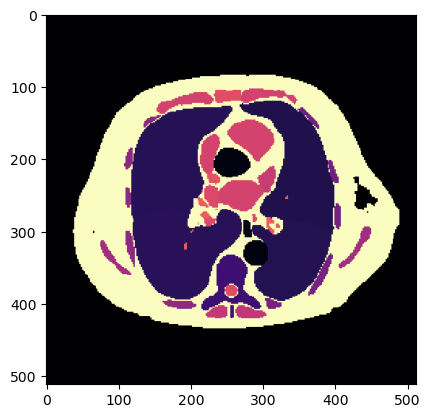

In [12]:
plt.imshow(mask[:,:,64].T, cmap='magma')

In [16]:
play_volume(mask, mode="mask", mask_type="totalsegmentator", axis=2)

In [15]:
play_volume(converted_mask, mode="mask", mask_type="totalsegmentator", axis=2)

In [4]:
mask_data = nib.load("./data/0120.nii.gz")
print("orientation:", nib.aff2axcodes(mask_data.affine))
target_orientation = ("L", "P", "S")
current_ornt = nib.orientations.io_orientation(mask_data.affine)
target_ornt = nib.orientations.axcodes2ornt(target_orientation)
transform = nib.orientations.ornt_transform(current_ornt, target_ornt)

mask_data = mask_data.as_reoriented(transform)
mask = mask_data.get_fdata()

print("converted orientation:", nib.aff2axcodes(mask_data.affine))
print("shape:", mask.shape)
print("unique values:", np.unique(mask))

orientation: ('R', 'A', 'S')
converted orientation: ('L', 'P', 'S')
shape: (512, 512, 128)
unique values: [  0.   1.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.  14.
  17.  19.  23.  28.  29.  30.  31.  32.  35.  36.  37.  38.  39.  40.
  41.  42.  43.  44.  45.  46.  47.  48.  49.  57.  62.  63.  64.  65.
  66.  67.  68.  69.  70.  71.  72.  73.  74.  75.  76.  77.  78.  79.
  80.  81.  82.  83.  84.  85.  86.  87.  88.  89.  90.  91.  92.  96.
 100. 104. 105. 106. 107. 108. 109. 110. 111. 112. 113. 114. 115. 119.
 121. 122. 123. 124. 125. 126. 132. 200.]


In [3]:
mask_data = nib.load("./data/0120-2^3.nii.gz")
print("orientation:", nib.aff2axcodes(mask_data.affine))
target_orientation = ("L", "P", "S")
current_ornt = nib.orientations.io_orientation(mask_data.affine)
target_ornt = nib.orientations.axcodes2ornt(target_orientation)
transform = nib.orientations.ornt_transform(current_ornt, target_ornt)

mask_data = mask_data.as_reoriented(transform)
mask_resized = mask_data.get_fdata()

print("converted orientation:", nib.aff2axcodes(mask_data.affine))
print("shape:", mask_resized.shape)
print("unique values:", np.unique(mask_resized))

orientation: ('R', 'A', 'S')
converted orientation: ('L', 'P', 'S')
shape: (256, 256, 128)
unique values: [  0.   1.   3.   4.   5.   6.   7.   8.   9.  11.  12.  13.  14.  17.
  23.  28.  29.  30.  31.  32.  36.  37.  38.  39.  40.  41.  42.  43.
  44.  45.  46.  47.  57.  62.  63.  64.  65.  66.  67.  68.  69.  70.
  71.  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.  84.
  85.  86.  88.  89.  90.  91.  92.  96. 100. 104. 105. 106. 107. 108.
 109. 110. 111. 112. 113. 114. 115. 119. 121. 122. 123. 124. 125. 126.
 132. 200.]


In [5]:
play_volume(mask_resized, mode="mask", mask_type="totalsegmentator", axis=2)

In [6]:
play_volume(mask, mode="mask", mask_type="totalsegmentator", axis=2)